In [15]:
"""
Análise de Poemas em Português com NLP

Objetivo:
- Analisar padrões linguísticos em poemas
- Comparar autores
- Aplicar TF, TF-IDF, stemming e lematização
"""

'\nAnálise de Poemas em Português com NLP\n\nObjetivo:\n- Analisar padrões linguísticos em poemas\n- Comparar autores\n- Aplicar TF, TF-IDF, stemming e lematização\n'

In [16]:
# Executar apenas uma vez:
# !pip install -r requirements.txt
# !python -m spacy download pt_core_news_sm

In [17]:
# =========================
# IMPORTAÇÕES
# =========================

# Manipulação de dados
import pandas as pd
import numpy as np
from collections import Counter

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import RSLPStemmer
import spacy

# Vetorização
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Similaridade
from sklearn.metrics.pairwise import cosine_similarity

# WordCloud
from wordcloud import WordCloud

# Downloads necessários
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('rslp')

# Carregar modelo spaCy
nlp = spacy.load("pt_core_news_sm")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\unico\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\unico\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\unico\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package rslp to
[nltk_data]     C:\Users\unico\AppData\Roaming\nltk_data...
[nltk_data]   Package rslp is already up-to-date!


In [18]:
# # Baixa dataset automaticamente do Kaggle

# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("oliveirasp6/poems-in-portuguese")

# print("Path to dataset files:", path)

# Tarefa 1: Preparação e Análise Exploratória

In [19]:
# =========================
# ANÁLISE EXPLORATÓRIA
# =========================
# Objetivo:
# - Entender estrutura dos dados
# - Ver distribuição de autores

# 1. Carregar o dataset
# df = pd.read_csv('../kaggle/input/poems-in-portuguese/portuguese-poems.csv', encoding='utf-8')
df = pd.read_csv('..\DATA\portuguese-poems.csv', encoding='utf-8')

In [20]:
# Verificação de qualidade dos dados
print("Valores nulos:\n", df.isnull().sum())
print("\nDuplicados:", df.duplicated().sum())
print("\nTipos:\n", df.dtypes)

Valores nulos:
 Author     0
Title      0
Content    2
Views      0
dtype: int64

Duplicados: 0

Tipos:
 Author     object
Title      object
Content    object
Views       int64
dtype: object


In [21]:
# Remoção dos nulos
df = df.dropna(subset = ['Content'])
print("Shape após remover nulos: ", df.shape)

Shape após remover nulos:  (15541, 4)


In [22]:
# O dataset contém mais de 15 mil poemas escritos por mais de 2000 autores.
# Após a remoção de valores nulos na coluna de conteúdo, restaram 15.541 poemas.
# Isso indica que o dataset possui boa qualidade e poucas inconsistências.

In [23]:
# 2. Explorar estrutura
print(f"Shape: {df.shape}")
print(f"Colunas: {df.columns.tolist()}")
df.head(10)

Shape: (15541, 4)
Colunas: ['Author', 'Title', 'Content', 'Views']


,Author,Title,Content,Views
0,Cecília Meireles,Retrato,"Eu não tinha este rosto de hoje,\r\nAssim calm...",1018431
1,Fernando Pessoa,"Para ser grande, sê inteiro: nada","Para ser grande, sê inteiro: nada\r\nTeu exage...",1979413
2,Marina Colasanti,"Eu sei, mas não devia",Eu sei que a gente se acostuma. Mas não devia....,301509
3,Carlos Drummond de Andrade,Quadrilha,João amava Teresa que amava Raimundo\r\nque am...,1421206
4,Eugénio de Andrade,É urgente o amor,É urgente o amor.\r\nÉ urgente um barco no mar...,621197
5,Vinicius de Moraes,Procura-se um amigo,"Não precisa ser homem, basta ser humano, basta...",942385
6,Fernando Pessoa,X. MAR PORTUGUÊS,"Ó mar salgado, quanto do teu sal\r\nSão lágrim...",1979414
7,Vinicius de Moraes,Eu sei e você sabe,Eu sei e você sabe\r\nJá que a vida quis assim...,942386
8,Gonçalves Dias,Como eu te amo,"Como se ama o silêncio, a luz, o aroma,\r\nO o...",581009
9,Manuel Bandeira,Poema tirado de uma notícia de jornal,João Gostoso era carregador de feira livre e m...,863828


In [24]:
# 3. Listar todos os autores
autores_unicos = df['Author'].unique()
print(f"Total de autores: {len(autores_unicos)}")
print(autores_unicos[:20])

Total de autores: 2127
['Cecília Meireles' 'Fernando Pessoa' 'Marina Colasanti'
 'Carlos Drummond de Andrade' 'Eugénio de Andrade' 'Vinicius de Moraes'
 'Gonçalves Dias' 'Manuel Bandeira' 'Sophia de Mello Breyner Andresen'
 'Chacal' 'Miguel Torga' 'Clarice Lispector' 'Thiago de Mello'
 'Bertolt Brecht' 'Florbela Espanca' 'João Roiz de Castelo-Branco'
 'Mário de Sá-Carneiro' "Alexandre O'Neill" 'José Gomes Ferreira'
 'Sebastião da Gama']


In [25]:
# 4. Contar poemas por autor
autor_counts = df['Author'].value_counts()
print(autor_counts.head(15))

Author
Fernando Pessoa                     2232
Sophia de Mello Breyner Andresen     441
Jorge Luis Borges                    417
Florbela Espanca                     347
Angela Santos                        257
Nuno Júdice                          231
Castro Alves                         222
Ruy Belo                             193
Reinaldo Ferreira                    101
Manuel António Pina                   98
Paulo Leminski                        97
Carlos Drummond de Andrade            91
Bocage                                88
Álvares de Azevedo                    86
Manuel Bandeira                       83
Name: count, dtype: int64


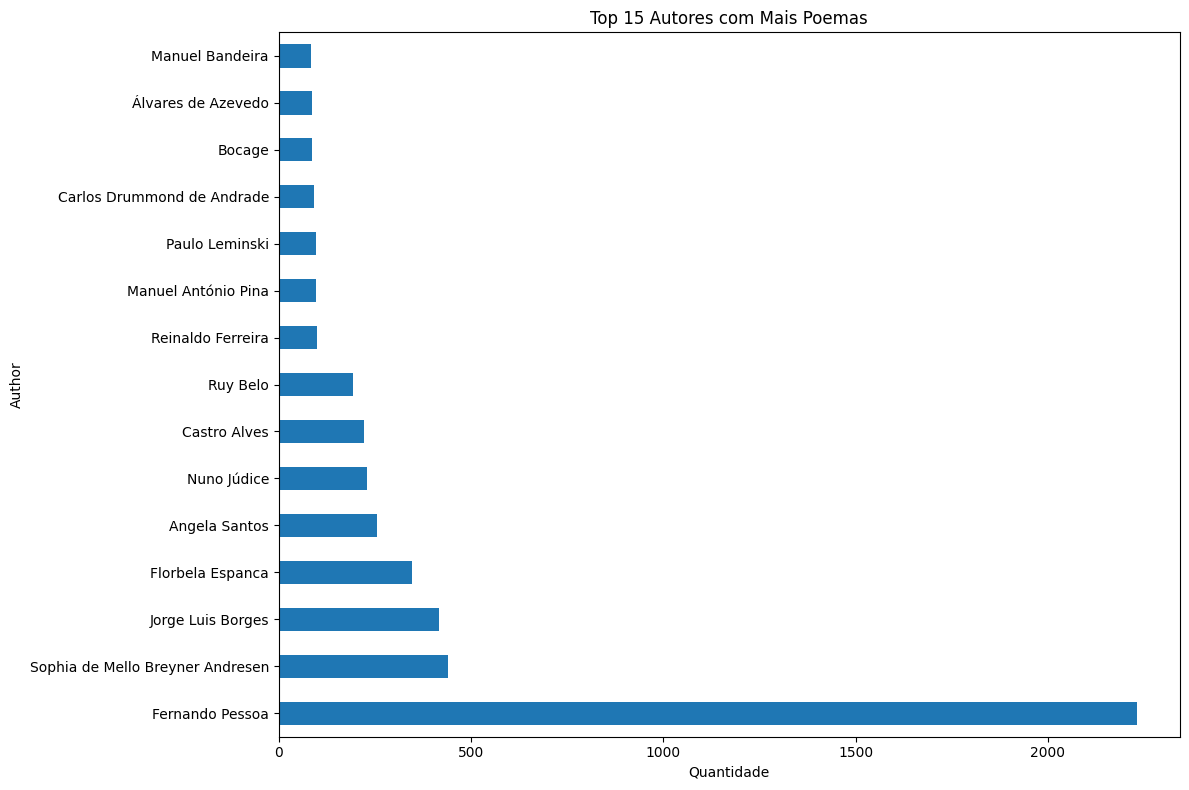

In [26]:
# 5. Visualizar distribuição
plt.figure(figsize=(12, 8))
autor_counts.head(15).plot(kind='barh')
plt.xlabel('Número de Poemas')
plt.title('Top 15 Autores com Mais Poemas')
plt.xlabel('Quantidade')
plt.tight_layout()
plt.savefig('autores_distribution.png', dpi=150)
plt.show()

In [ ]:
# Observa-se uma grande desigualdade na distribuição de poemas entre os autores.
# Esse tipo de distribuição indica que o dataset é fortemente desbalanceado. Podendo impactar análises baseadas em frequência
# Ex: TF, word clouds, vocabulário global
# Esse desequilíbrio justifica a decisão de filtrar autores específicos para análise comparativa, 
# permitindo observar diferenças estilísticas sem que um único autor domine as estatísticas globais.

In [27]:
# O dataset possui grande diversidade de autores (mais de 2000).
# No entanto, existe forte concentração em alguns autores,
# especialmente Fernando Pessoa, que possui mais de 2200 poemas.
#
# Essa concentração pode influenciar análises estatísticas,
# pois autores com mais poemas tendem a dominar as frequências de palavras.

In [28]:
# 6. Filtrar autores selecionados
selecionados = ['Fernando Pessoa', 'Angela Santos', 'Sophia de Mello Breyner Andresen']
df_pessoa = df[df['Author'].isin(selecionados)].copy()

print(f"\nPoemas de Fernando Pessoa, Angela Santos e Sophia de Mello Breyner Andresen: {len(df_pessoa)}")
print(df_pessoa['Author'].value_counts())


Poemas de Fernando Pessoa, Angela Santos e Sophia de Mello Breyner Andresen: 2930
Author
Fernando Pessoa                     2232
Sophia de Mello Breyner Andresen     441
Angela Santos                        257
Name: count, dtype: int64


# Tarefa 2: Pré-processamento de Texto em Português

In [29]:
# =========================
# PRÉ-PROCESSAMENTO
# =========================
# Etapas:
# - Lowercase
# - Remoção de pontuação
# - Remoção de números
# - Tokenização
# - Remoção de stopwords

In [30]:
# Carregar stopwords português
stop_words = set(stopwords.words('portuguese'))

In [31]:
# Limpeza de prepocessamento

def preprocessar(texto):
  # Converte todo o texto para minúsculas
  # Isso evita que "Amor" e "amor" sejam tratados como palavras diferentes
  texto = texto.lower()
  # Limpar pontuações e caracteres
  texto = re.sub(r'[,.:;!?\'"-()\\[\\}{}]]', ' ', texto)
  # Remover digítos
  texto = re.sub(r'\d+', '', texto)
  # Diminuir espaços em branco
  texto = re.sub(r'\s+', ' ', texto)

  return texto

df_pessoa['texto_limpo'] = df_pessoa['Content'].apply(preprocessar)

# Esta etapa realiza a normalização inicial do texto.
# Ao remover pontuações, números e padronizar para minúsculas,
# evitamos que variações superficiais afetem a análise de frequência
# e os cálculos de TF e TF-IDF.


In [32]:
# 3. Tokenização e remoção de stopwords
def remover_stopwords(texto):
    # Tokenização: transforma o texto em lista de palavras
    tokens = word_tokenize(texto, language='portuguese')
    # Remove stopwords e tokens muito curtos
    return [token for token in tokens if token not in stop_words and len(token) > 2]

df_pessoa['tokens'] = df_pessoa['texto_limpo'].apply(remover_stopwords)
df_pessoa['num_tokens'] = df_pessoa['tokens'].apply(len)

# Stopwords são palavras muito frequentes na língua (ex: "de", "a", "o", "que").
# Elas geralmente não contribuem para identificar temas ou estilos.
# Removê-las ajuda a destacar palavras mais informativas do texto.

In [33]:
# 4. Comparação de impacto
tokens_antes = df_pessoa['texto_limpo'].apply(
    lambda x: len(word_tokenize(x, language='portuguese'))).mean()
tokens_depois = df_pessoa['num_tokens'].mean()

print(f"Média de tokens ANTES remover stopwords: {tokens_antes:.2f}")
print(f"Média de tokens APÓS remover stopwords: {tokens_depois:.2f}")
print(f"Redução: {((tokens_antes - tokens_depois) / tokens_antes * 100):.2f}%")

Média de tokens ANTES remover stopwords: 123.99
Média de tokens APÓS remover stopwords: 60.75
Redução: 51.00%


In [34]:
# A remoção de stopwords reduziu aproximadamente 51% dos tokens.
# Isso mostra que grande parte do texto é composta por palavras
# funcionais da língua (como artigos, preposições e conjunções).
#
# Essa etapa é importante para destacar palavras com maior
# conteúdo semântico na análise textual.

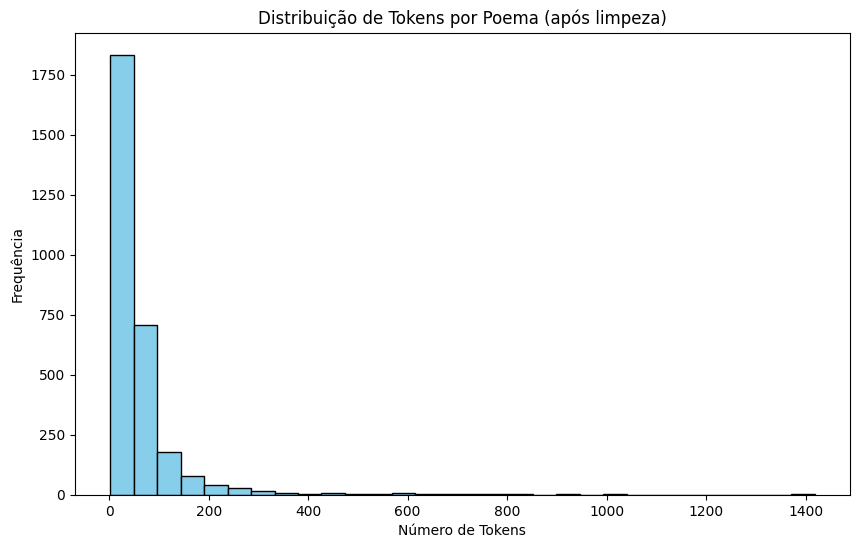

In [35]:
# 5. Visualizar distribuição
plt.figure(figsize=(10, 6))
plt.hist(df_pessoa['num_tokens'], bins=30, edgecolor='black', color='skyblue')
plt.xlabel('Número de Tokens')
plt.ylabel('Frequência')
plt.title('Distribuição de Tokens por Poema (após limpeza)')
plt.savefig('tokens_distribution.png', dpi=150)
plt.show()

In [ ]:
# Análise da distribuição de tokens
# A maioria dos poemas possui entre 20 e 100 tokens após o pré-processamento.
# A distribuição apresenta assimetria positiva, com alguns poemas muito longos
# (outliers) ultrapassando 1000 tokens. Esse comportamento é comum em datasets
# de poesia e justifica o uso de técnicas como TF-IDF para normalizar o impacto
# de documentos maiores nas análises de frequência.

In [36]:
# =========================
# NORMALIZAÇÃO DE TEXTO
# =========================
# Stemming: reduz palavras ao radical
# Lematização: reduz para forma base (mais precisa)

In [37]:
# O stemmer RSLP é específico para português
stemmer = RSLPStemmer()

In [38]:
# O stemming reduz palavras ao seu radical
def aplicar_stemming(tokens):
  return [stemmer.stem(t) for t in tokens]

# Retorna o lema de cada palavra
def aplicar_lematizacao(texto):
  # Processa o texto com o modelo linguístico
  documentos = nlp(texto)
  # Retorna o lema de cada palavra
  return [token.lemma_ for token in documentos if token.is_alpha and not token.is_stop]

df_pessoa['tokens_stem'] = df_pessoa['tokens'].apply(aplicar_stemming)
df_pessoa['tokens_lemma'] = df_pessoa['texto_limpo'].apply(aplicar_lematizacao)

df_pessoa['texto_stem'] = df_pessoa['tokens_stem'].apply(lambda x: ' '.join(x))
df_pessoa['texto_lemma'] = df_pessoa['tokens_lemma'].apply(lambda x: ' '.join(x))

# O stemming reduz diferentes variações de uma palavra ao mesmo radical.
#
# Isso ajuda a agrupar palavras com o mesmo significado,
# mas pode gerar radicais que não existem como palavras reais.

# A lematização reduz palavras à sua forma canônica (lemma).
# Exemplos: amando -> amar
#
# Diferente do stemming, a lematização mantém palavras reais da língua,
# tornando os resultados mais interpretáveis semanticamente.


In [39]:
print("COMPARAÇÃO:")

for i in range(2):
    print("\nORIGINAL:", df_pessoa['Content'].iloc[i][:100])
    print("BASE:", df_pessoa['texto_limpo'].iloc[i][:100])
    print("STEM:", df_pessoa['texto_stem'].iloc[i][:100])
    print("LEMMA:", df_pessoa['texto_lemma'].iloc[i][:100])

COMPARAÇÃO:

ORIGINAL: Para ser grande, sê inteiro: nada
Teu exagera ou exclui.
Sê todo em cada coisa. Põe quanto és
No 
BASE: para ser grande, sê inteiro: nada teu exagera ou exclui. sê todo em cada coisa. põe quanto és no mín
STEM: grand int nad exag exclu tod cad cois põe quant mín faz assim cad lag lua tod brilh porqu alt viv
LEMMA: sê inteiro exagerar excluir sê pequeno lago lua brilha alto viver

ORIGINAL: Ó mar salgado, quanto do teu sal
São lágrimas de Portugal!
Por te cruzarmos, quantas mães choraram
BASE: ó mar salgado, quanto do teu sal são lágrimas de portugal! por te cruzarmos, quantas mães choraram, 
STEM: mar salg quant sal lágr portug cruz quant mão chor quant filh vão rez quant noiv fic cas foss mar va
LEMMA: ó mar salgar sal lágrima Portugal cruzarmos quanto mães chorar quanto filho rezar quanto noivo ficar


# Tarefa 3: Vetorização com TF (CountVectorizer)

In [40]:
# =========================
# BAG OF WORDS (TF)
# =========================
# Conta frequência das palavras

In [41]:
# 1. Preparar textos limpos como strings
textos = df_pessoa['texto_limpo'].values

In [42]:
# 2. CountVectorizer com unigramas, cria uma matriz de frequência de termos
vectorizer_tf = CountVectorizer(
    lowercase=True,
    stop_words= list(stop_words),
    ngram_range=(1, 1),
    max_features=500
)

In [43]:
# 3. Treinar e transformar
# Ajusta o modelo aos textos e gera a matriz
X_tf = vectorizer_tf.fit_transform(textos)

feature_names = vectorizer_tf.get_feature_names_out()

In [44]:
# 4. Calcular frequências
 # Soma as frequências de cada termo
term_freq = np.asarray(X_tf.sum(axis=0)).flatten()

term_freq_sorted = sorted(zip(feature_names, term_freq),
                        key=lambda x: x[1], reverse=True)

# TF mede quantas vezes cada palavra aparece no conjunto de textos.
# Palavras com alta frequência podem indicar temas recorrentes
# ou elementos característicos do estilo do autor.

In [45]:
# 5. Top 20 termos mais frequentes
print("=== Top 20 Termos Mais Frequentes (Unigramas) ===")
for i, (termo, freq) in enumerate(term_freq_sorted[:20], 1):
    print(f"{i:2d}. {termo:15s} : {int(freq):4d}")

=== Top 20 Termos Mais Frequentes (Unigramas) ===
 1. the             : 2283
 2. and             : 1809
 3. of              : 1414
 4. vida            : 1180
 5. tudo            : 1152
 6. mim             : 1102
 7. to              : 1052
 8. alma            :  955
 9. that            :  908
10. onde            :  892
11. nada            :  816
12. in              :  788
13. porque          :  722
14. my              :  707
15. sei             :  683
16. is              :  636
17. dia             :  606
18. mundo           :  567
19. noite           :  565
20. ter             :  557


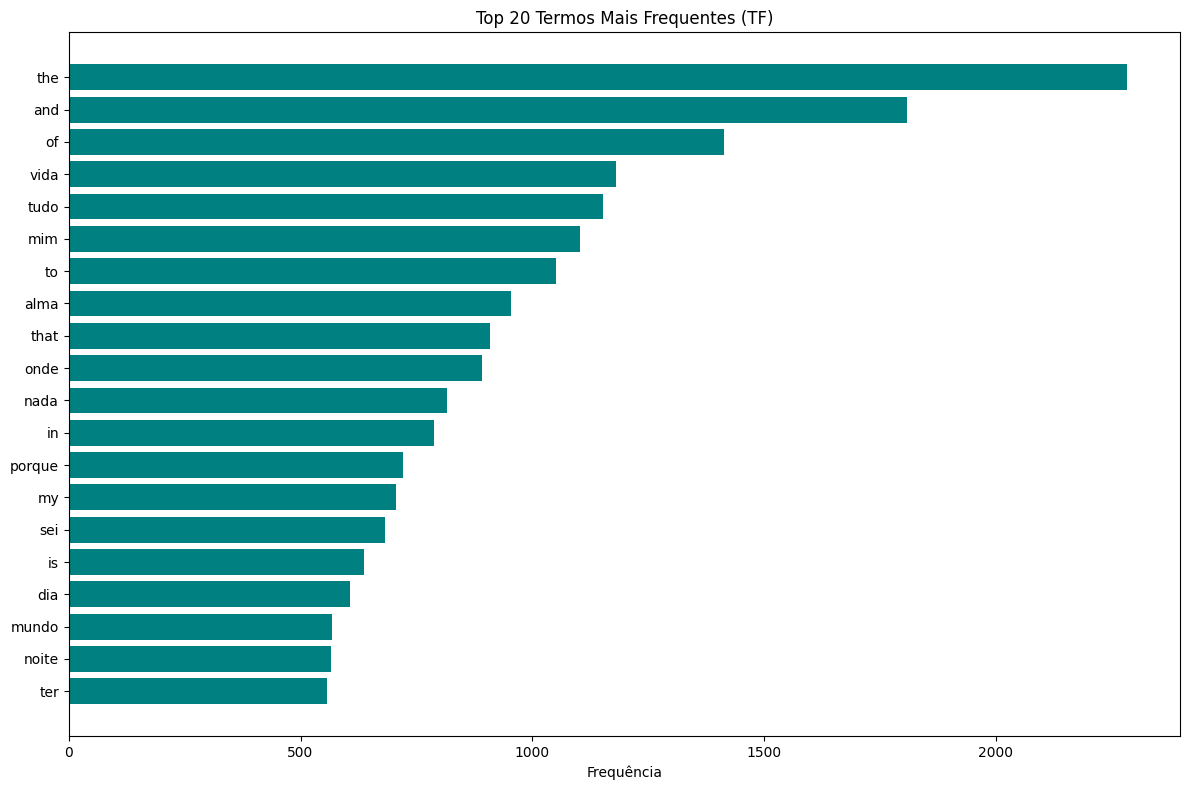

In [46]:
# 6. Visualizar
top_20 = term_freq_sorted[:20]
termos = [t[0] for t in top_20]
freqs = [t[1] for t in top_20]

plt.figure(figsize=(12, 8))
plt.barh(termos, freqs, color='teal')
plt.xlabel('Frequência')
plt.title('Top 20 Termos Mais Frequentes (TF)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('top_terms_tf_unigrams.png', dpi=150)
plt.show()

In [ ]:
#A análise de frequência (TF) revelou forte presença de palavras funcionais da língua inglesa,
#  como “the”, “and” e “of”, indicando que o corpus contém poemas multilíngues 
# ou traduzidos. Esse fator introduz ruído na análise, podendo comprometer a interpretação dos padrões linguísticos.

#Ainda assim, termos como “vida”, “alma” e “mundo” aparecem com alta frequência,
#  sugerindo que os poemas abordam temas existenciais e subjetivos,
#  característicos da poesia lírica.

In [47]:
# 7. Bigramas
print("\n=== Bigramas Mais Frequentes ===")

vectorizer_bigram = CountVectorizer(
    lowercase=True,
    stop_words=list(stop_words),
    ngram_range=(2, 2),
    max_features=100
)

X_bigram = vectorizer_bigram.fit_transform(textos)

bigram_names = vectorizer_bigram.get_feature_names_out()

bigram_freq = np.asarray(X_bigram.sum(axis=0)).flatten()

bigram_sorted = sorted(zip(bigram_names, bigram_freq),
                    key=lambda x: x[1], reverse=True)

for i, (bigrama, freq) in enumerate(bigram_sorted[:10], 1):
    print(f"{i:2d}. {bigrama:25s} : {int(freq):3d}")


=== Bigramas Mais Frequentes ===
 1. breyner andresen          : 360
 2. mello breyner             : 360
 3. sophia mello              : 308
 4. and the                   : 166
 5. of the                    : 165
 6. in the                    : 152
 7. qualquer coisa            :  96
 8. my soul                   :  84
 9. andresen antologia        :  83
10. moraes editores           :  82


In [48]:
def top_tf(textos):
    vectorizer = CountVectorizer(max_features=15)
    X = vectorizer.fit_transform(textos)
    names = vectorizer.get_feature_names_out()
    freq = np.asarray(X.sum(axis=0)).flatten()
    sorted_terms = sorted(zip(names, freq), key=lambda x: x[1], reverse=True)

    for t, f in sorted_terms[:10]:
        print(f"{t:25s} : {int(f):3d}")

print("\nTF ORIGINAL:")
top_tf(df_pessoa['texto_limpo'])

print("\nTF STEM:")
top_tf(df_pessoa['texto_stem'])

print("\nTF LEMMA:")
top_tf(df_pessoa['texto_lemma'])


TF ORIGINAL:
que                       : 10868
de                        : 8321
não                       : 4405
do                        : 3563
me                        : 3334
se                        : 3123
em                        : 2771
um                        : 2628
da                        : 2558
the                       : 2283

TF STEM:
the                       : 2497
and                       : 1950
tod                       : 1329
vid                       : 1215
tud                       : 1148
mim                       : 1104
alm                       : 1026
ond                       : 1013
outr                      : 955
olh                       : 952

TF LEMMA:
the                       : 2283
and                       : 1808
of                        : 1410
vida                      : 1206
haver                     : 1173
eu                        : 1098
to                        : 1013
alma                      : 937
that                      : 908
ser        

In [49]:
# Observa-se que alguns termos frequentes aparecem em inglês
# (como "the", "and", "of"), indicando que o dataset contém
# poemas traduzidos ou multilíngues.
#
# Isso evidencia a importância da escolha adequada de stopwords
# e possíveis etapas adicionais de normalização linguística.

# Tarefa 4: Vetorização com TF-IDF

In [50]:
# =========================
# TF-IDF
# =========================
# Mede importância da palavra no corpus

In [51]:
# 1. TfidfVectorizer
vectorizer_tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words=list(stop_words),
    ngram_range=(1, 1),
    max_features=500,
    norm='l2'
)

In [52]:
# 2. Treinar e transformar
X_tfidf = vectorizer_tfidf.fit_transform(textos)
tfidf_names = vectorizer_tfidf.get_feature_names_out()

In [53]:
# 3. Calcular scores TF-IDF globais
tfidf_scores = np.asarray(X_tfidf.sum(axis=0)).flatten()
tfidf_sorted = sorted(zip(tfidf_names, tfidf_scores),
                    key=lambda x: x[1], reverse=True)

print("=== Top 15 Termos por TF-IDF (Global) ===")
for i, (termo, score) in enumerate(tfidf_sorted[:15], 1):
    print(f"{i:2d}. {termo:15s} : {score:.6f}")

# TF-IDF identifica palavras importantes considerando dois fatores:
#
# TF (Term Frequency):
# quantas vezes a palavra aparece
#
# IDF (Inverse Document Frequency):
# quão rara a palavra é no conjunto de documentos
#
# Isso faz com que palavras comuns em todos os poemas tenham
# peso menor, enquanto palavras distintivas ganham maior relevância.

=== Top 15 Termos por TF-IDF (Global) ===
 1. vida            : 113.399455
 2. the             : 101.662031
 3. mim             : 101.319995
 4. tudo            : 100.738008
 5. nada            : 90.989212
 6. onde            : 89.970834
 7. alma            : 89.925159
 8. sei             : 81.010299
 9. dia             : 79.268327
10. porque          : 77.630331
11. and             : 77.144475
12. mar             : 73.532100
13. noite           : 69.769764
14. coração         : 67.089395
15. andresen        : 66.533223


In [54]:
# Diferentemente do TF, o TF-IDF destacou palavras com maior
# relevância semântica nos poemas, como "vida", "alma", "coração".
#
# Isso ocorre porque o TF-IDF penaliza palavras muito frequentes
# no corpus e valoriza termos que aparecem em contextos mais específicos.
#
# Dessa forma, o TF-IDF tende a capturar melhor temas recorrentes
# da poesia, como sentimentos, existência e subjetividade.

In [55]:
# Comparação STEM vs LEMMA
def top_tfidf(textos):
    vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words=list(stop_words),
    ngram_range=(1, 1),
    max_features=500,
    norm='l2'
)
    X = vectorizer.fit_transform(textos)
    feature_names = vectorizer.get_feature_names_out()
    tfidf_scores = np.asarray(X.sum(axis=0)).flatten()
    tfidf_sorted =  sorted(zip(feature_names, tfidf_scores),
                    key=lambda x: x[1], reverse=True)
    for i, (termo, score) in enumerate(tfidf_sorted[:15], 1):
      print(f"{i:2d}. {termo:15s} : {score:.6f}")

print("TF-IDF ORIGINAL:", top_tfidf(df_pessoa['texto_limpo']))
print("\nTF-IDF STEM:", top_tfidf(df_pessoa['texto_stem']))
print("\nTF-IDF LEMMA:", top_tfidf(df_pessoa['texto_lemma']))

 1. vida            : 113.399455
 2. the             : 101.662031
 3. mim             : 101.319995
 4. tudo            : 100.738008
 5. nada            : 90.989212
 6. onde            : 89.970834
 7. alma            : 89.925159
 8. sei             : 81.010299
 9. dia             : 79.268327
10. porque          : 77.630331
11. and             : 77.144475
12. mar             : 73.532100
13. noite           : 69.769764
14. coração         : 67.089395
15. andresen        : 66.533223
TF-IDF ORIGINAL: None
 1. the             : 128.172566
 2. vid             : 100.591945
 3. and             : 98.737107
 4. mim             : 91.680705
 5. tud             : 90.608589
 6. tod             : 90.222833
 7. ond             : 89.698598
 8. olh             : 89.596198
 9. alm             : 84.913391
10. pens            : 83.129167
11. outr            : 81.769625
12. pass            : 81.644410
13. dia             : 81.378309
14. nad             : 80.514139
15. sent            : 79.059528

TF-IDF STEM

In [56]:
# Comparação entre stemming e lematização
#
# O stemming reduz palavras para radicais, o que pode gerar formas
# que não existem no idioma, mas ajuda a agrupar variações rapidamente.
#
# A lematização mantém palavras válidas da língua portuguesa,
# o que torna a interpretação dos resultados mais clara.
#
# Em análises exploratórias e visualizações (como wordcloud),
# a lematização tende a produzir resultados mais interpretáveis.

In [57]:
# 4. Comparar TF vs TF-IDF por autor
print("\n=== Comparação TF vs TF-IDF por Autor ===")
for autor in selecionados:
    textos_autor = df_pessoa[df_pessoa['Author'] == autor]['texto_lemma'].values

    if len(textos_autor) > 0:
        # TF
        vect_tf_autor = CountVectorizer(
            lowercase=True,
            stop_words=list(stop_words),
            max_features=15
        )
        X_tf_autor = vect_tf_autor.fit_transform(textos_autor)
        tf_nomes = vect_tf_autor.get_feature_names_out()
        tf_freq = np.asarray(X_tf_autor.sum(axis=0)).flatten()
        tf_sorted = sorted(zip(tf_nomes, tf_freq), key=lambda x: x[1], reverse=True)

        # TF-IDF
        vect_tfidf_autor = TfidfVectorizer(
            lowercase=True,
            stop_words=list(stop_words),
            max_features=15,
            norm='l2'
        )
        X_tfidf_autor = vect_tfidf_autor.fit_transform(textos_autor)
        tfidf_nomes = vect_tfidf_autor.get_feature_names_out()
        tfidf_scores_autor = np.asarray(X_tfidf_autor.sum(axis=0)).flatten()
        tfidf_sorted_autor = sorted(zip(tfidf_nomes, tfidf_scores_autor),
                                key=lambda x: x[1], reverse=True)

        print(f"\n{'='*50}")
        print(f"AUTOR: {autor}")
        print(f"{'='*50}")
        print(f"{'Top 10 por TF':<35} | {'Top 10 por TF-IDF':<35}")
        print("-" * 72)
        for j in range(10):
            tf_item = f"{j+1}. {tf_sorted[j][0]}" if j < len(tf_sorted) else ""
            tfidf_item = f"{j+1}. {tfidf_sorted_autor[j][0]}" if j < len(tfidf_sorted_autor) else ""
            print(f"{tf_item:<35} | {tfidf_item:<35}")


=== Comparação TF vs TF-IDF por Autor ===

AUTOR: Fernando Pessoa
Top 10 por TF                       | Top 10 por TF-IDF                  
------------------------------------------------------------------------
1. the                              | 1. vida                            
2. and                              | 2. alma                            
3. of                               | 3. pensar                          
4. to                               | 4. dia                             
5. vida                             | 5. mundo                           
6. that                             | 6. deus                            
7. alma                             | 7. passar                          
8. in                               | 8. the                             
9. my                               | 9. and                             
10. is                              | 10. of                             

AUTOR: Angela Santos
Top 10 por TF           

In [58]:
# A comparação entre TF e TF-IDF mostra diferenças importantes:
#
# TF destaca palavras mais frequentes no corpus,
# incluindo palavras funcionais ou comuns.
#
# TF-IDF destaca palavras mais informativas,
# que ajudam a caracterizar melhor o conteúdo dos poemas.
#
# Assim, o TF é útil para identificar frequência,
# enquanto o TF-IDF é mais adequado para análise semântica.

In [59]:
# 5. Testar normalizações L1 vs L2
print("\n=== Comparação L1 vs L2 ===")
vect_l1 = TfidfVectorizer(norm='l1', max_features=100, lowercase=True, stop_words=list(stop_words))
vect_l2 = TfidfVectorizer(norm='l2', max_features=100, lowercase=True, stop_words=list(stop_words))

X_l1 = vect_l1.fit_transform(textos)
X_l2 = vect_l2.fit_transform(textos)

print(f"Norma L1 (Manhattan) - Soma de um vetor: {X_l1[0].sum():.6f}")
print(f"Norma L2 (Euclidiana) - Norma de um vetor: {np.sqrt((X_l2[0].data**2).sum()):.6f}")


=== Comparação L1 vs L2 ===
Norma L1 (Manhattan) - Soma de um vetor: 1.000000
Norma L2 (Euclidiana) - Norma de um vetor: 1.000000


In [60]:
# A normalização garante que todos os vetores TF-IDF tenham
# a mesma escala.
#
# A norma L1 normaliza pela soma dos valores,
# enquanto a norma L2 normaliza pela distância euclidiana.
#
# Ambas ajudam a evitar que documentos maiores dominem
# os cálculos de similaridade.

# Tarefa 5: Visualização com Word Clouds

In [61]:
# =========================
# VISUALIZAÇÃO
# =========================
# WordCloud para interpretar frequências

Gerando word clouds por autor...
  ✓ Salvo: wordcloud_fernando_pessoa.png


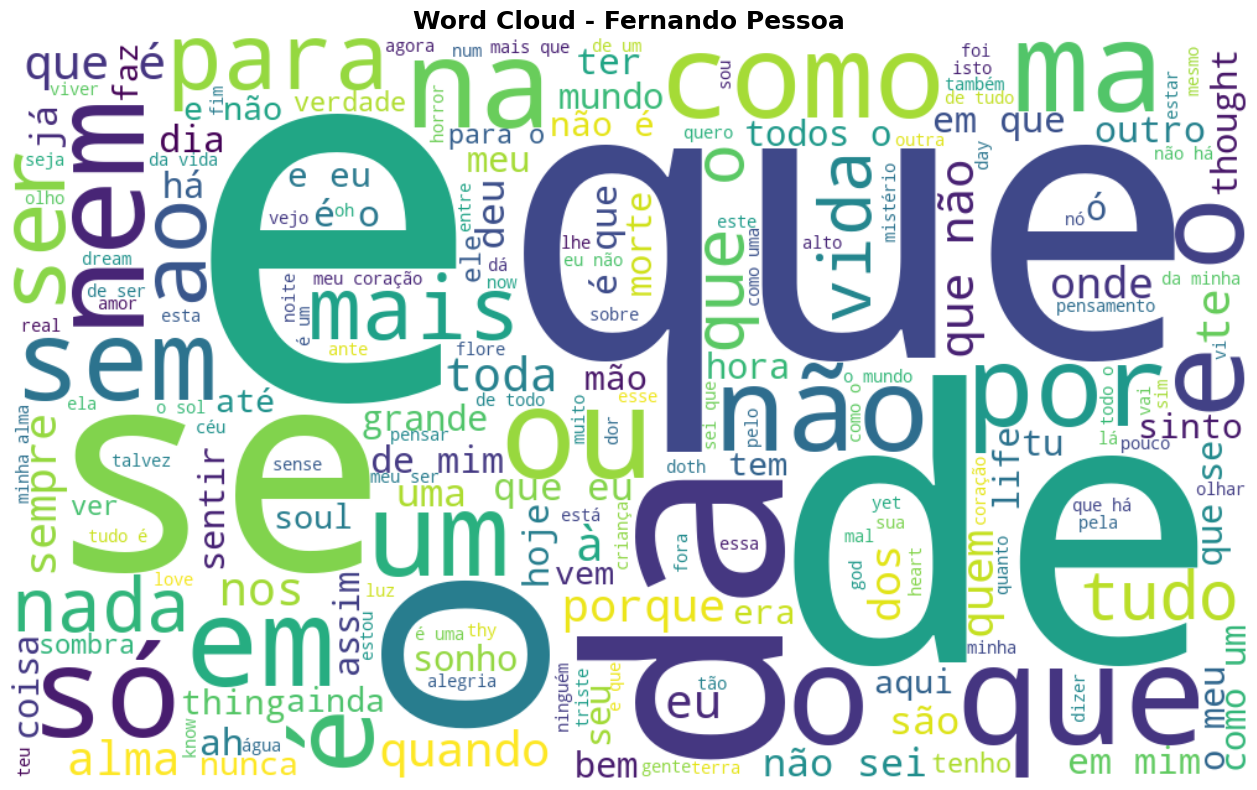

  ✓ Salvo: wordcloud_angela_santos.png


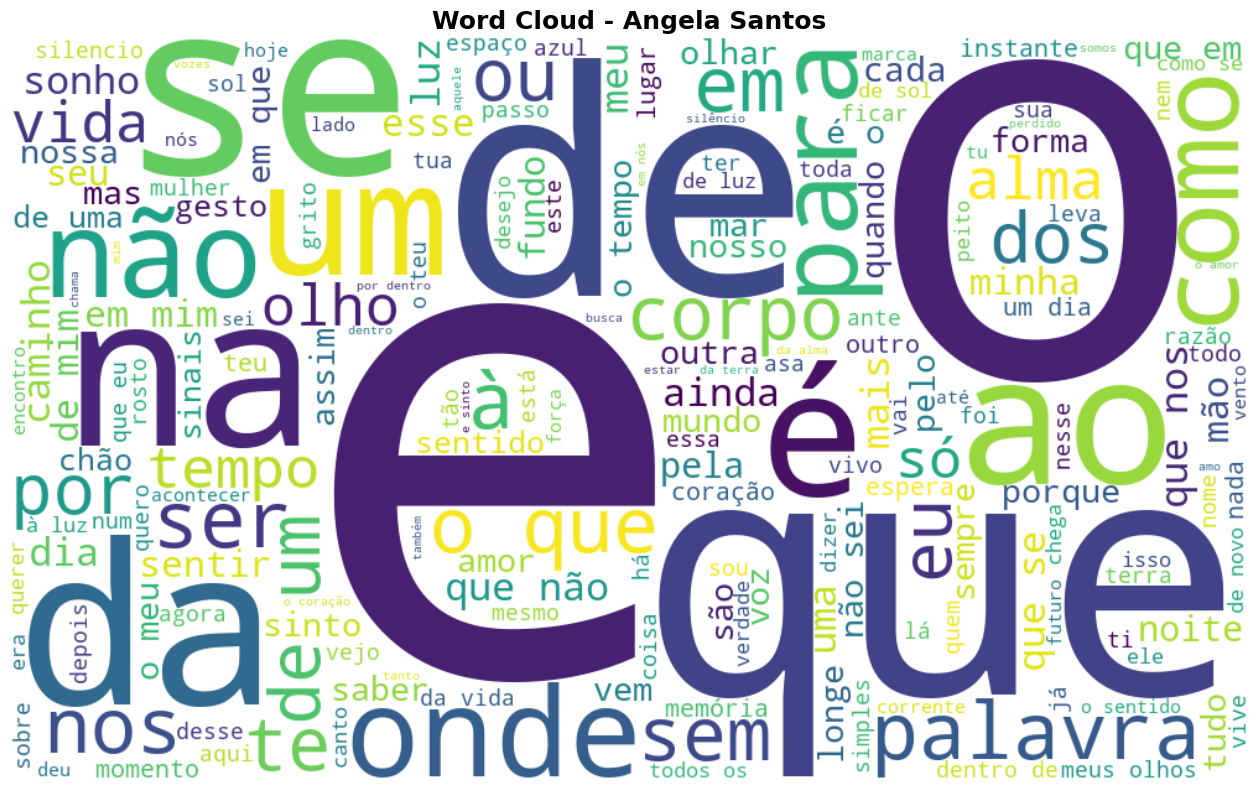

  ✓ Salvo: wordcloud_sophia_de_mello_breyner_andresen.png


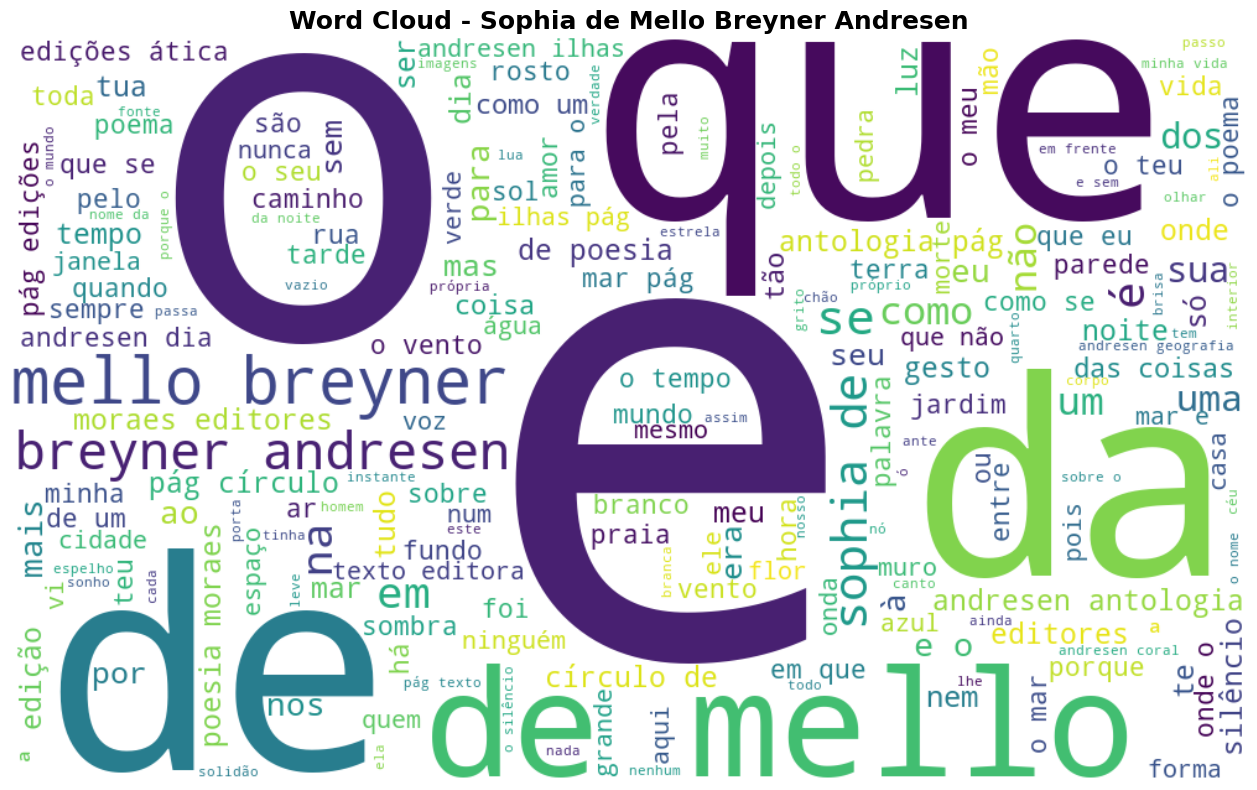

In [62]:
# 1. Word Cloud por Autor
print("Gerando word clouds por autor...")
for autor in selecionados:
    textos_autor = ' '.join(df_pessoa[df_pessoa['Author'] == autor]['texto_limpo'].values)

    if len(textos_autor) > 50:  # Apenas se houver texto suficiente
        wc = WordCloud(
            width=1000,
            height=600,
            background_color='white',
            colormap='viridis',
            prefer_horizontal=0.7,
            random_state=42
        ).generate(textos_autor)

        plt.figure(figsize=(15, 8))
        plt.imshow(wc, interpolation='bilinear')
        plt.title(f'Word Cloud - {autor}', fontsize=18, fontweight='bold')
        plt.axis('off')
        plt.tight_layout()
        filename = f'wordcloud_{autor.replace(" ", "_").lower()}.png'
        plt.savefig(filename, dpi=150, bbox_inches='tight')
        print(f"  ✓ Salvo: {filename}")
        plt.show()

In [63]:
# A WordCloud permite visualizar rapidamente as palavras
# mais frequentes nos poemas de Fernando Pessoa.
#
# O tamanho de cada palavra representa sua frequência
# no conjunto de poemas analisados.
#
# Esse tipo de visualização facilita identificar temas
# recorrentes no estilo do autor.

✓ Salvo: wordcloud_tf_vs_tfidf_comparison.png


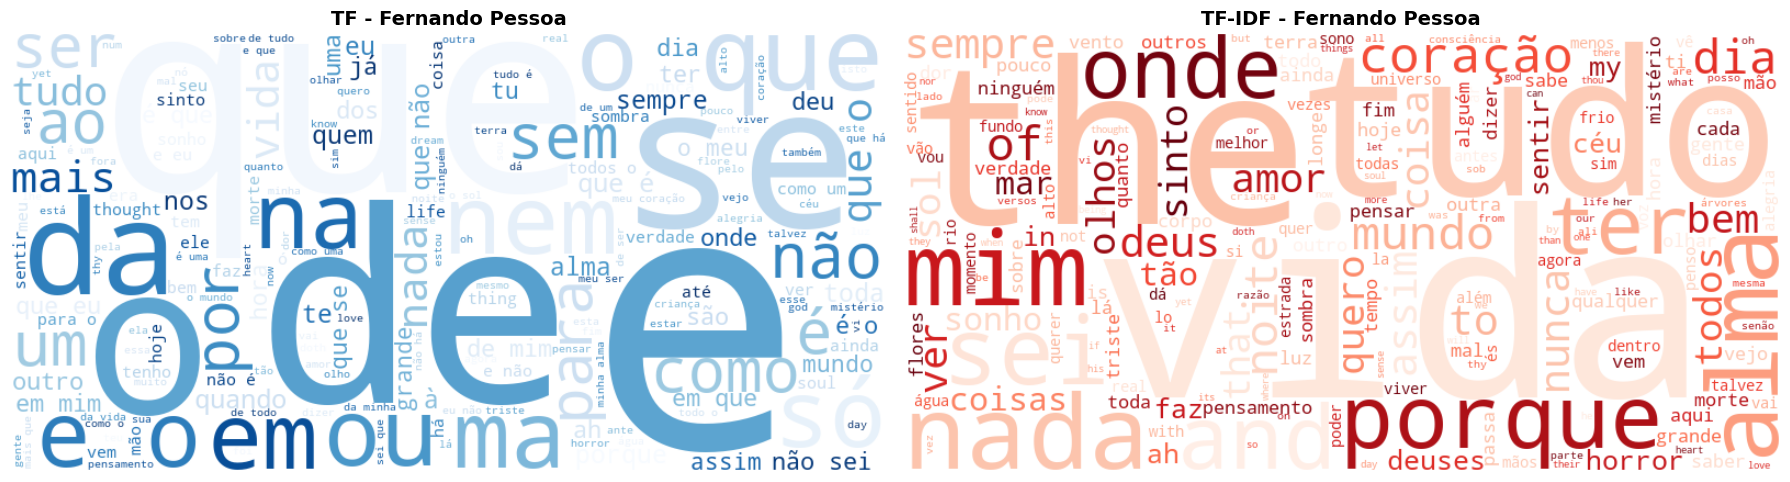

In [64]:
# 2. Word Cloud TF vs TF-IDF para um autor
autor_escolhido = 'Fernando Pessoa'
textos_escolhido_lista = df_pessoa[df_pessoa['Author'] == autor_escolhido]['texto_limpo'].values

# Mantém seu texto concatenado (TF usa isso)
textos_escolhido = ' '.join(textos_escolhido_lista)

if len(textos_escolhido) > 50:
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # =========================
    # TF (igual ao seu)
    # =========================
    wc_tf = WordCloud(width=800, height=400, background_color='white',
                      colormap='Blues', random_state=42).generate(textos_escolhido)

    axes[0].imshow(wc_tf, interpolation='bilinear')
    axes[0].set_title(f'TF - {autor_escolhido}', fontsize=14, fontweight='bold')
    axes[0].axis('off')

    # =========================
    # TF-IDF (CORRIGIDO)
    # =========================
    vectorizer = TfidfVectorizer(
        stop_words= list(stop_words),
        max_features=200
    )

    X = vectorizer.fit_transform(textos_escolhido_lista)

    feature_names = vectorizer.get_feature_names_out()
    tfidf_scores = np.asarray(X.sum(axis=0)).flatten()

    tfidf_dict = dict(zip(feature_names, tfidf_scores))

    wc_tfidf = WordCloud(width=800, height=400, background_color='white',
                         colormap='Reds', random_state=42).generate_from_frequencies(tfidf_dict)

    axes[1].imshow(wc_tfidf, interpolation='bilinear')
    axes[1].set_title(f'TF-IDF - {autor_escolhido}', fontsize=14, fontweight='bold')
    axes[1].axis('off')

    plt.tight_layout()
    plt.savefig('wordcloud_tf_vs_tfidf_comparison.png', dpi=150, bbox_inches='tight')
    print("✓ Salvo: wordcloud_tf_vs_tfidf_comparison.png")

    plt.show()

In [65]:
# WordCloud TF vs TF-IDF
#
# O WordCloud baseado em TF mostra as palavras mais frequentes
# no conjunto de poemas.
#
# Já o WordCloud baseado em TF-IDF destaca palavras que são
# mais características de determinados poemas ou autores,
# reduzindo o peso de palavras muito comuns.
#
# Dessa forma, TF revela popularidade de termos,
# enquanto TF-IDF revela relevância contextual.

✓ Salvo: wordcloud_triplo_fernando_pessoa.png


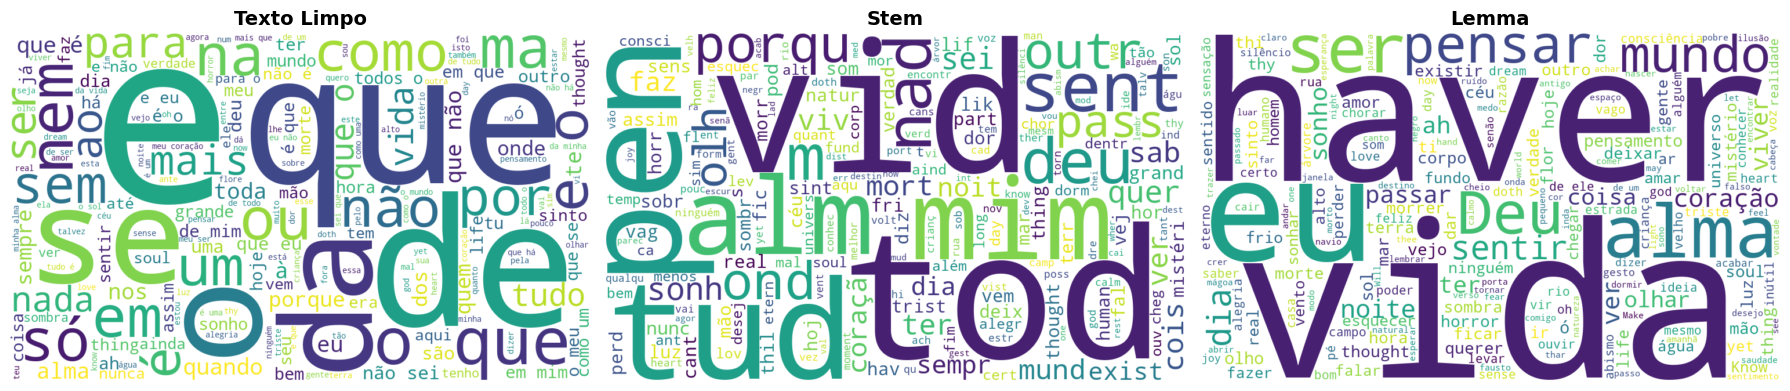

In [66]:
autor = 'Fernando Pessoa'

# Junta os textos
texto_limpo = ' '.join(df_pessoa[df_pessoa['Author']==autor]['texto_limpo'])
texto_stem  = ' '.join(df_pessoa[df_pessoa['Author']==autor]['texto_stem'])
texto_lemma = ' '.join(df_pessoa[df_pessoa['Author']==autor]['texto_lemma'])

# Configuração padrão (igual ao seu primeiro código)
wc_config = dict(
    width=1000,
    height=600,
    background_color='white',
    colormap='viridis',
    prefer_horizontal=0.7,
    random_state=42
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Original ---
if len(texto_limpo) > 50:
    wc1 = WordCloud(**wc_config).generate(texto_limpo)
    axes[0].imshow(wc1, interpolation='bilinear')
    axes[0].set_title("Texto Limpo", fontsize=14, fontweight='bold')

# --- Stem ---
if len(texto_stem) > 50:
    wc2 = WordCloud(**wc_config).generate(texto_stem)
    axes[1].imshow(wc2, interpolation='bilinear')
    axes[1].set_title("Stem", fontsize=14, fontweight='bold')

# --- Lemma ---
if len(texto_lemma) > 50:
    wc3 = WordCloud(**wc_config).generate(texto_lemma)
    axes[2].imshow(wc3, interpolation='bilinear')
    axes[2].set_title("Lemma", fontsize=14, fontweight='bold')

# Remove eixos
for ax in axes:
    ax.axis('off')

plt.tight_layout()

# Salvar igual ao outro padrão
filename = f'wordcloud_triplo_{autor.replace(" ", "_").lower()}.png'
plt.savefig(filename, dpi=150, bbox_inches='tight')

print(f"✓ Salvo: {filename}")

plt.show()

# Tarefa 6: Análise de Similaridade entre Poemas (Desafio)

In [67]:
# =========================
# SIMILARIDADE ENTRE POEMAS
# =========================
# Usa cosine similarity para medir proximidade semântica

In [68]:
# 1. Calcular matriz de similaridade
similarity_matrix = cosine_similarity(X_tfidf)

In [69]:
# 2. Selecionar um poema de referência
idx_campos = (df_pessoa['Author'] == 'Fernando Pessoa').values
indices_campos = np.where(idx_campos)[0]

if len(indices_campos) > 0:
    idx_referencia = indices_campos[0]
    similares = similarity_matrix[idx_referencia].argsort()[::-1][1:6]

    print(f"\n{'='*70}")
    print(f"POEMA DE REFERÊNCIA: {df_pessoa.iloc[idx_referencia]['Author']}")
    print(f"{'='*70}")
    print(f"{df_pessoa.iloc[idx_referencia]['texto_limpo'][:200]}...\n")

    print("POEMAS MAIS SIMILARES:")
    for i, idx_similar in enumerate(similares, 1):
        sim_score = similarity_matrix[idx_referencia, idx_similar]
        autor = df_pessoa.iloc[idx_similar]['Author']
        texto = df_pessoa.iloc[idx_similar]['texto_limpo'][:150]
        print(f"\n{i}. [{sim_score:.4f}] {autor}")
        print(f"   {texto}...")


POEMA DE REFERÊNCIA: Fernando Pessoa
para ser grande, sê inteiro: nada teu exagera ou exclui. sê todo em cada coisa. põe quanto és no mínimo que fazes. assim em cada lago a lua toda brilha, porque alta vive....

POEMAS MAIS SIMILARES:

1. [0.4029] Fernando Pessoa
   cada um é um mundo; e como em cada fonte uma deidade vela, em cada homem porque não há de haver um deus só de ele homem? na encoberta sucessão das cou...

2. [0.3811] Angela Santos
   tudo me lembra o imundo e de beleza é a sede dos meus olhos de cada fibra do meu corpo de cada nervo que me percorre tudo me lembra o imundo e cada ge...

3. [0.3634] Angela Santos
   subrepticiamente um tremor se anuncia nas profundezas lateja nas veias, em cada fibra, em cada músculo e emerge à terra de ninguém onde me abandonei.....

4. [0.3612] Fernando Pessoa
   na ponta de cada baioneta luzem os olhos de kant, hegel é disparado das goelas de cada canhão e as grandes hostes calmas avançando para a morte são go...

5. [0.3598] Fernando Pe

In [70]:
# A similaridade entre poemas foi calculada utilizando
# a métrica de similaridade do cosseno.
#
# Essa métrica mede o ângulo entre dois vetores TF-IDF,
# indicando o quanto dois poemas são semanticamente próximos.
#
# Valores próximos de 1 indicam alta similaridade,
# enquanto valores próximos de 0 indicam textos diferentes.

In [71]:
# 3. Comparar com outro autor (Jorge Luis Borges)
idx_reis = (df['Author'] == 'Jorge Luis Borges').values
indices_reis = np.where(idx_reis)[0]

if len(indices_reis) > 0:
    idx_ref_reis = indices_reis[0]
    similares_reis = similarity_matrix[idx_ref_reis].argsort()[::-1][1:6]

    print(f"\n{'='*70}")
    print(f"POEMA DE REFERÊNCIA: Jorge Luis Borges")
    print(f"{'='*70}")
    print(f"{df_pessoa.iloc[idx_ref_reis]['Content'][:200]}...\n")

    print("POEMAS MAIS SIMILARES:")
    for i, idx_sim in enumerate(similares_reis, 1):
        sim_score = similarity_matrix[idx_ref_reis, idx_sim]
        autor = df_pessoa.iloc[idx_sim]['Author']
        texto = df_pessoa.iloc[idx_sim]['texto_limpo'][:150]
        print(f"\n{i}. [{sim_score:.4f}] {autor}")
        print(f"   {texto}...")


POEMA DE REFERÊNCIA: Jorge Luis Borges
Escorraçadas do pecado e do sagrado Habitam agora a mais íntima humildade Do quotidiano. São Torneira que se estraga atraso de autocarro Sopa que transborda na panela Caneta que se perde aspirador que...

POEMAS MAIS SIMILARES:

1. [0.4594] Sophia de Mello Breyner Andresen
   neste dia de mar e nevoeiro é tão próximo o teu rosto são os longos horizontes os ritmos soltos dos ventos e aquelas aves que desde o princípio das es...

2. [0.4525] Sophia de Mello Breyner Andresen
   nostalgia sem nome da paisagem,secreto murmurar de cada imagem,que na escuridão se ergue e caminha.sophia de mello breyner andresen | "dia do mar", pá...

3. [0.4393] Angela Santos
   o dia virá ao dobrar duma esquina onde a espera se fez longa e os dias escritos correram sem se cumprir o dia virá e longe as incertezas plenas nossas...

4. [0.4365] Sophia de Mello Breyner Andresen
   como um oásis branco era o meu dia nele secretamente eu navegava unicamente o vento me seguia

In [72]:
# Conclusão da análise

# A comparação entre as técnicas mostrou que:

# - O pré-processamento reduz significativamente o ruído textual
# - A remoção de stopwords melhora a identificação de termos relevantes
# - O stemming agrupa variações de palavras, mas reduz interpretabilidade
# - A lematização preserva significado linguístico
# - TF destaca palavras frequentes
# - TF-IDF destaca palavras distintivas

# Essas técnicas combinadas permitem explorar padrões linguísticos
# e diferenças estilísticas entre autores.

In [73]:
# Sumário dos resultados
print("\n" + "="*70)
print("SUMÁRIO DA ANÁLISE")
print("="*70)

print(f"\n1. DATASET:")
print(f"   • Total de poemas: {len(df_pessoa)}")
print(f"   • Autores analisados: {selecionados}")
print(f"   • Distribuição: {dict(df_pessoa['Author'].value_counts())}")

print(f"\n2. VOCABULÁRIO:")
print(f"   • Termos únicos totais: {len(feature_names)}")
print(f"   • Termo mais frequente: '{term_freq_sorted[0][0]}' ({int(term_freq_sorted[0][1])} ocorrências)")
print(f"   • Comprimento médio de poema: {df_pessoa['num_tokens'].mean():.0f} tokens")

print(f"\n3. TERMOS DISCRIMINATIVOS (TF-IDF):")
print(f"   • Top 3 globais: {', '.join([t[0] for t in tfidf_sorted[:3]])}")

print(f"\n4. BIGRAMAS:")
print(f"   • Bigrama mais frequente: '{bigram_sorted[0][0]}' ({int(bigram_sorted[0][1])} ocorrências)")

print("\n" + "="*70 + "\n")


SUMÁRIO DA ANÁLISE

1. DATASET:
   • Total de poemas: 2930
   • Autores analisados: ['Fernando Pessoa', 'Angela Santos', 'Sophia de Mello Breyner Andresen']
   • Distribuição: {'Fernando Pessoa': np.int64(2232), 'Sophia de Mello Breyner Andresen': np.int64(441), 'Angela Santos': np.int64(257)}

2. VOCABULÁRIO:
   • Termos únicos totais: 200
   • Termo mais frequente: 'the' (2283 ocorrências)
   • Comprimento médio de poema: 61 tokens

3. TERMOS DISCRIMINATIVOS (TF-IDF):
   • Top 3 globais: vida, the, mim

4. BIGRAMAS:
   • Bigrama mais frequente: 'breyner andresen' (360 ocorrências)


